In [146]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import nbinom

sns.set_theme(style="whitegrid", context="talk")

# Exercises part I: random problems

## Choosing the right support and avoiding aliasing

1) Change the value of N, first pick N > 13, then N < 13. What do you notice?

2) n ∈ {0, 1, ..., N - 1} is the support of your probability distribution. When N-1 is below 12, we have aliasing. Fix N = 10, and now vary r between 0 and 1, What happens?
https://cosmo-notes.github.io/pgfunk/chapters/numerical_inversion.html
A lot is said about about aliasing here - especially about selecting the correct value of `r`. To select a reasonable `r`, we can write `r` <-> e^-1/k, where k should be around a few magnitudes smaller than N (usually).

3) Instead of rolling two dice, now get the probability distribution for the sum of 3 dice. Repeat for more dice (5,10,20). What is the shape of the resulting probability distribution?

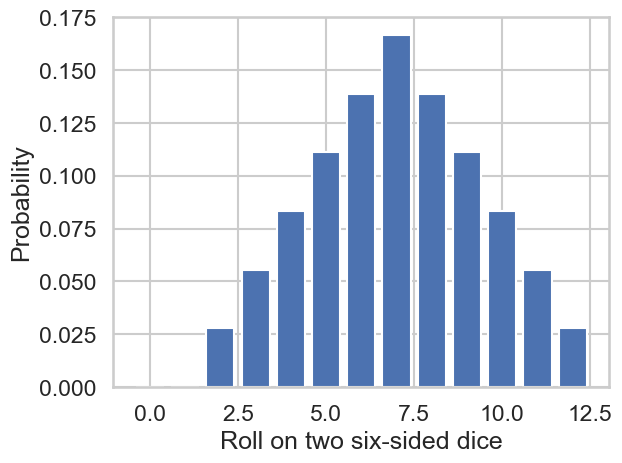

In [147]:
r = 1.
g = lambda x: np.sum([x**n/6 for n in range(1,7)])
G = lambda x: g(x)**2
G = np.vectorize(G)
N = 13
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Roll on two six-sided dice')
plt.show()

# More complex scenarios

1) Get the probability distribution for the sum of a six-sided die and a twelve-sided die.

2) You have dice of a very weird shape. The PGF for the roll of a single die is 
g(x) = e^x-1. Extract the probability distribution and make sure you eliminate aliasing effects. Do the same using two dice.

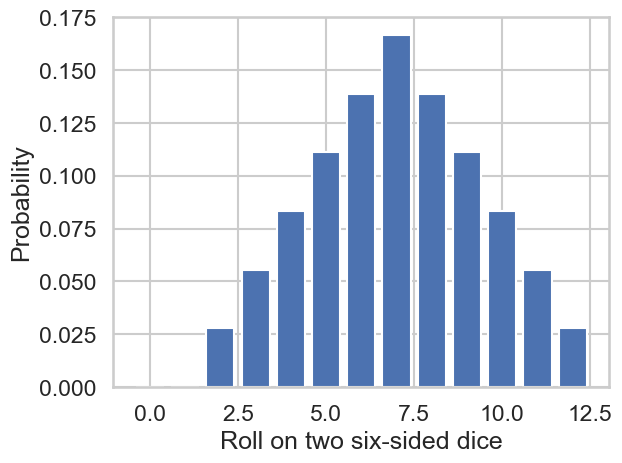

In [148]:
r = 1.
g = lambda x: np.sum([x**n/6 for n in range(1,7)])
G = lambda x: g(x)**2
G = np.vectorize(G)
N = 13
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Roll on two six-sided dice')
plt.show()

# Survival probability
## Question 1: PGF for a single engine

For a single engine at time $t$:

$$g(x,t) = P(X_i(t) = 0) \cdot x^0 + P(X_i(t) = 1) \cdot x^1$$

Where:
- $P(X_i(t) = 0) = \sum_{s=0}^{t} p_s$ (cumulative probability of failure by time $t$)
- $P(X_i(t) = 1) = 1 - \sum_{s=0}^{t} p_s$ (survival probability at time $t$)

Therefore:
$$g(x,t) = \left(\sum_{s=0}^{t} p_s\right) + \left(1 - \sum_{s=0}^{t} p_s\right) x$$

Or more compactly, if we define $q(t) = 1 - \sum_{s=0}^{t} p_s$ as the survival probability:
$$g(x,t) = (1 - q(t)) + q(t) \cdot x$$

---

## Question 2: PGF for all 12 engines

Since all engines are independent and identically distributed:

$$G(x,t) = [g(x,t)]^{12}$$

The distribution $p_{n,t}$ represents:
- $p_{n,t}$ = probability that exactly $n$ engines (out of 12) are operational at time $t$
- This answers: "What's the probability of having exactly 0, 1, 2, ..., or 12 working engines at time $t$?"

---

## Question 3: Probability of survival with each prototype
- Probability of survival with Engine A: 0.3495
- Probability of survival with Engine B: 0.8160

---

## Question 4: Probability of survival with 6 engines of type a and b
6A, 6B: 0.6149

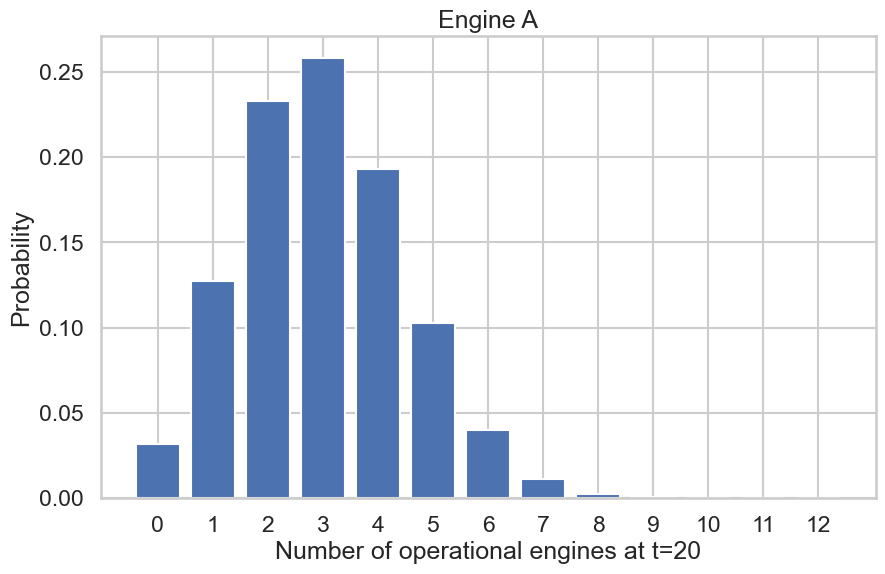

Probability of survival with Engine A: 0.3495


In [149]:
# Calculate survival probability at t=20 for both engines
t_mission = np.arange(0, 21)
cumulative_failure_prob_A = np.sum(nbinom.pmf(t_mission, 32, 0.65))
cumulative_failure_prob_B = np.sum(nbinom.pmf(t_mission, 5, 0.2))  # Fixed: use t_mission, not t
survival_prob_A = 1 - cumulative_failure_prob_A
survival_prob_B = 1 - cumulative_failure_prob_B

# PGF for a single engine
g_1 = lambda x, y: (1 - y) + y * x

# PGF for all 12 engines - raise the entire PGF to the 12th power
g_12 = lambda x, y: (g_1(x, y))**12  # Fixed: raise g_1(x,y) to power 12
g_12 = np.vectorize(g_12)

# Extract probability distribution
N = 13  # 0 to 12 engines can be working
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)
pn_A = abs(np.fft.fft(g_12(c, survival_prob_A))/N)  # Fixed: use g_12, not G_A

# Plot
plt.figure(figsize=(10, 6))
plt.bar(n, pn_A)
plt.ylabel('Probability')
plt.xlabel('Number of operational engines at t=20')
plt.title('Engine A')
plt.xticks(n)  # This forces ticks at integer values: 0, 1, 2, 3, ..., 12
plt.show()

# Probability of survival (at least 4 engines working)
prob_survival_A = np.sum(pn_A[4:])
print(f"Probability of survival with Engine A: {prob_survival_A:.4f}")

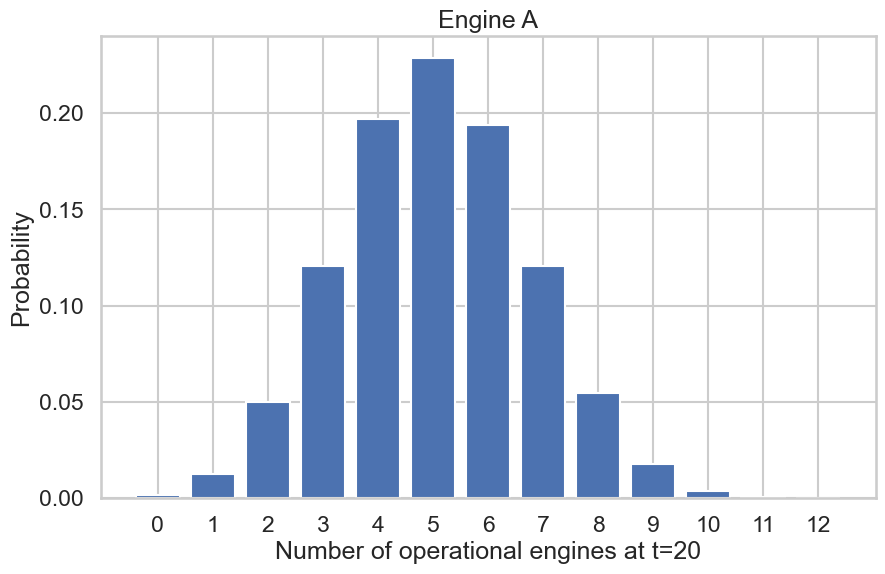

Probability of survival with Engine B: 0.8160


In [150]:
pn_B = abs(np.fft.fft(g_12(c, survival_prob_B))/N)  # Fixed: use g_12, not G_A

# Plot
plt.figure(figsize=(10, 6))
plt.bar(n, pn_B)
plt.ylabel('Probability')
plt.xlabel('Number of operational engines at t=20')
plt.title('Engine A')
plt.xticks(n)  # This forces ticks at integer values: 0, 1, 2, 3, ..., 12
plt.show()

# Probability of survival (at least 4 engines working)
prob_survival_B = np.sum(pn_B[4:])
print(f"Probability of survival with Engine B: {prob_survival_B:.4f}")

In [151]:
results = []
for n_A in range(13):  # 0 to 12 engines of type A
    n_B = 12 - n_A
    
    # Combined PGF
    G_mix = lambda x: (g_1(x, survival_prob_A)**n_A) * (g_1(x, survival_prob_B)**n_B)
    G_mix = np.vectorize(G_mix)
    
    # Extract probabilities
    pn_mix = abs(np.fft.fft(G_mix(c))/N)
    
    # Survival probability (at least 4 engines)
    prob_survival = np.sum(pn_mix[4:])
    results.append((n_A, n_B, prob_survival))
    print(f"{n_A}A, {n_B}B: {prob_survival:.4f}")

# Find optimal mix
optimal = max(results, key=lambda x: x[2])
print(f"\nOptimal: {optimal[0]}A, {optimal[1]}B with {optimal[2]:.4f} survival probability")

0A, 12B: 0.8160
1A, 11B: 0.7893
2A, 10B: 0.7599
3A, 9B: 0.7276
4A, 8B: 0.6926
5A, 7B: 0.6549
6A, 6B: 0.6149
7A, 5B: 0.5727
8A, 4B: 0.5289
9A, 3B: 0.4841
10A, 2B: 0.4387
11A, 1B: 0.3936
12A, 0B: 0.3495

Optimal: 0A, 12B with 0.8160 survival probability


# Bacterial colony

## Question 1: 
$
g(x) = (1-p) + p x^2
$

---

## Question 2
To find the mean, we leverage the PGF property, which states that we can arrive at the mean by taking the first derivative of $g(x)$ and evaluating at 1.

$g'(x) = 2px$

$g'(1) = 2p$

Now if we evaluate at different values of $p$:

$\langle k \rangle = 2 * .25 = 0.5$ high probability of extinction

$\langle k \rangle = 2 * .50 = 1.0$ something close to a tipping point

$\langle k \rangle = 2 * .75 = 1.5$ population could survive


In [152]:
p_values = [0.25, 0.5, 0.75]

for p in p_values:
    Q = lambda x: (1-p) + p*x**2
    G0 = lambda x: x**10
    
    x = c.copy()
    x = Q(x)  # Apply once to get generation 1
    pn = abs(np.fft.fft(G0(x))/N)
    
    print(f"\np = {p}:")
    print(f"  P(n=0) = {pn[0]:.6f} (extinction)")
    print(f"  P(n=2) = {pn[2]:.6f}")
    print(f"  P(n=4) = {pn[4]:.6f}")
    print(f"  P(n=6) = {pn[6]:.6f}")
    print(f"  Most likely: n = {np.argmax(pn)}")
    print(f"  Mean: {np.sum(n * pn):.2f}")


p = 0.25:
  P(n=0) = 0.056314 (extinction)
  P(n=2) = 0.187712
  P(n=4) = 0.281568
  P(n=6) = 0.250282
  Most likely: n = 4
  Mean: 4.95

p = 0.5:
  P(n=0) = 0.000977 (extinction)
  P(n=2) = 0.009766
  P(n=4) = 0.043945
  P(n=6) = 0.117188
  Most likely: n = 10
  Mean: 7.77

p = 0.75:
  P(n=0) = 0.000001 (extinction)
  P(n=2) = 0.000029
  P(n=4) = 0.000386
  P(n=6) = 0.003090
  Most likely: n = 3
  Mean: 4.91


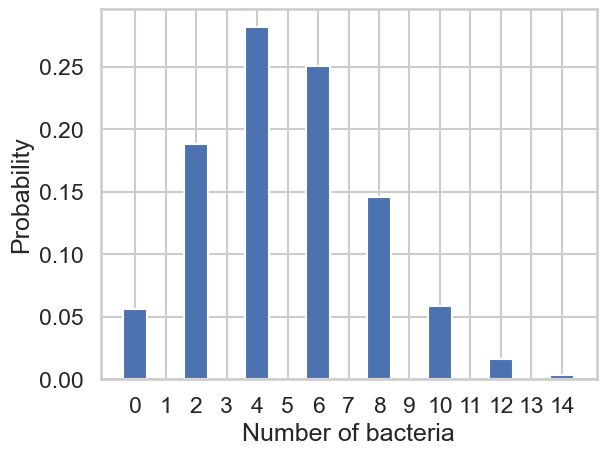

In [169]:

# Single bacterium offspring PGF
p = 0.25
Q = lambda x: (1-p) + p*x**2

# Initial population: 10 bacteria
G0 = lambda x: x**10

# FFT setup
N = 15  # Only need ~30 points max for this distribution
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)

# Get generation 1 distribution
pn = abs(np.fft.fft(G0(Q(c)))/N)

# Create bar graph
# plt.figure(figsize=(10, 6))
plt.xticks(n)
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Number of bacteria')
plt.show()